# Chapter 6 Teaching Notebook: AIS Trajectory Clustering

This notebook demonstrates a complete workflow for maritime trajectory pattern mining and clustering. It first loads AIS records, splits them into individual vessel trajectories, extracts critical points, clusters those points using KMeans, and then performs trajectory-level clustering using DTW and DBSCAN.

The code is organized as a teaching example. The computational logic is kept unchanged, while the comments and explanations are written in English for textbook use.


## 1. Import required libraries

The imports are consolidated here to avoid repeated import statements in later cells.


In [1]:
import os
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from sklearn.cluster import KMeans


## 2. Load AIS data

The input file is expected to contain AIS messages with vessel identifiers, timestamps, positions, and navigation variables.


In [2]:
df = pd.read_csv('../data/AIS_data.csv')


## 3. Split AIS messages into trajectories

A new trajectory is created whenever the time gap between two consecutive records from the same vessel exceeds a predefined threshold. This step converts raw AIS points into trajectory-level samples.


In [11]:
# =========================
# 1. Parameter settings
# =========================
ship_col = "IMO"
time_col = "Date/Time"

gap_threshold_hours = 6

# =========================
# 2. Copy the original AIS data
# =========================
df_traj = df.copy()

# Preserve the original row index for later tracing
df_traj["_original_index"] = df_traj.index

# Convert timestamps to datetime format
df_traj[time_col] = pd.to_datetime(df_traj[time_col], errors="coerce")

# Remove records with missing IMO or timestamp values
df_traj = df_traj.dropna(subset=[ship_col, time_col]).copy()

# Sort records by IMO and timestamp
df_traj = df_traj.sort_values([ship_col, time_col]).reset_index(drop=True)

# =========================
# 3. Compute the time gap between consecutive records for each IMO
# =========================
df_traj["prev_time"] = df_traj.groupby(ship_col)[time_col].shift(1)

df_traj["time_gap_from_prev_hour"] = (
    df_traj[time_col] - df_traj["prev_time"]
).dt.total_seconds() / 3600

# =========================
# 4. Identify the starting point of a new trajectory
# =========================
# Condition 1: the first record of the IMO
# Condition 2: the time gap from the previous record exceeds the threshold
df_traj["is_new_trajectory"] = (
    df_traj["prev_time"].isna() |
    (df_traj["time_gap_from_prev_hour"] > gap_threshold_hours)
)

# =========================
# 5. Generate global trajectory IDs
# =========================
# trajectory_id is numbered sequentially as 1, 2, 3, 4, ...
df_traj["trajectory_id"] = df_traj["is_new_trajectory"].cumsum()

# =========================
# 6. Summarize the results
# =========================
print("Trajectory segmentation completed")
print("Total number of AIS points:", len(df_traj))
print("Number of vessels by IMO:", df_traj[ship_col].nunique())
print("Number of trajectories by trajectory_id:", df_traj["trajectory_id"].nunique())

# Count the number of points in each trajectory
traj_summary = (
    df_traj.groupby(["trajectory_id", ship_col])
    .agg(
        start_time=(time_col, "min"),
        end_time=(time_col, "max"),
        point_count=(time_col, "count")
    )
    .reset_index()
)

print("\nFirst five rows of the trajectory summary:")
display(traj_summary.head())

# Preview the new AIS dataset
df_traj.head()


Trajectory segmentation completed
Total number of AIS points: 428341
Number of vessels by IMO: 775
Number of trajectories by trajectory_id: 3810

First five rows of the trajectory summary:


,trajectory_id,IMO,start_time,end_time,point_count
0,1,8320559,2021-02-18 00:27:00,2021-02-18 10:15:00,118
1,2,8320559,2021-09-14 06:36:00,2021-09-14 21:29:00,92
2,3,9001057,2021-01-16 22:26:00,2021-01-17 12:49:00,124
3,4,9001057,2021-01-22 11:21:00,2021-01-22 23:39:00,97
4,5,9001057,2021-01-26 11:40:00,2021-01-27 02:28:00,93


,IMO,Date/Time,Lat,Lng,Heading,SOG,COG,draught,Navigation status,_original_index,prev_time,time_gap_from_prev_hour,is_new_trajectory,trajectory_id
0,8320559,2021-02-18 00:27:00,35.077778,128.679722,182.0,11.5,189.0,8.5,Under Way,158054,NaT,NaN,True,1
1,8320559,2021-02-18 00:32:00,35.060556,128.683889,136.0,11.0,142.0,8.5,Under Way,158055,2021-02-18 00:27:00,0.083333,False,1
2,8320559,2021-02-18 00:38:00,35.050556,128.701667,116.0,11.4,119.0,8.5,Under Way,158056,2021-02-18 00:32:00,0.100000,False,1
3,8320559,2021-02-18 00:43:00,35.043333,128.720278,111.0,11.1,112.0,8.5,Under Way,158057,2021-02-18 00:38:00,0.083333,False,1
4,8320559,2021-02-18 00:44:00,35.043056,128.720833,110.0,11.1,112.0,8.5,Under Way,158058,2021-02-18 00:43:00,0.016667,False,1


## 4. Extract critical points

Critical points are selected from each trajectory according to turning-angle changes and large time gaps. These points are useful for identifying route changes, maneuvering locations, and sparse-observation segments.


In [16]:
# =========================
# 1. Parameter settings
# =========================
trajectory_col = "trajectory_id"   # Trajectory ID column
time_col = "Date/Time"
lat_col = "Lat"
lon_col = "Lng"

turn_threshold = 60          # Turning-angle threshold, in degrees
time_gap_threshold = 40      # Time-gap threshold, in minutes

output_path = "critical_points.csv"

# =========================
# 2. Data preparation
# =========================
df_work = df_traj.copy()

df_work[time_col] = pd.to_datetime(df_work[time_col], errors="coerce")
df_work[lat_col] = pd.to_numeric(df_work[lat_col], errors="coerce")
df_work[lon_col] = pd.to_numeric(df_work[lon_col], errors="coerce")

# Remove records with missing key fields
df_work = df_work.dropna(subset=[trajectory_col, time_col, lat_col, lon_col]).copy()

# Sort by trajectory ID and timestamp
df_work = df_work.sort_values([trajectory_col, time_col]).reset_index(drop=True)

# =========================
# 3. Define bearing and angular-difference functions
# =========================
def calculate_bearing(lat1, lon1, lat2, lon2):
    """
    Compute the bearing from point 1 to point 2, returned in the range 0-360 degrees.
    """
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlon = lon2 - lon1

    x = np.sin(dlon) * np.cos(lat2)
    y = (
        np.cos(lat1) * np.sin(lat2)
        - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    )

    bearing = np.degrees(np.arctan2(x, y))
    bearing = (bearing + 360) % 360

    return bearing


def angle_difference(angle1, angle2):
    """
    Compute the minimum angular difference between two directions, returned in the range 0-180 degrees.
    """
    return np.abs((angle1 - angle2 + 180) % 360 - 180)

# =========================
# 4. Extract previous and next points within each trajectory
# =========================
g = df_work.groupby(trajectory_col, group_keys=False)

df_work["prev_lat"] = g[lat_col].shift(1)
df_work["prev_lon"] = g[lon_col].shift(1)
df_work["next_lat"] = g[lat_col].shift(-1)
df_work["next_lon"] = g[lon_col].shift(-1)

df_work["prev_time"] = g[time_col].shift(1)
df_work["next_time"] = g[time_col].shift(-1)

# =========================
# 5. Compute the turning angle at each current point
# =========================
# Incoming direction: previous point -> current point
df_work["bearing_in_deg"] = calculate_bearing(
    df_work["prev_lat"],
    df_work["prev_lon"],
    df_work[lat_col],
    df_work[lon_col]
)

# Outgoing direction: current point -> next point
df_work["bearing_out_deg"] = calculate_bearing(
    df_work[lat_col],
    df_work[lon_col],
    df_work["next_lat"],
    df_work["next_lon"]
)

# Turning angle at the current point
df_work["turn_angle_deg"] = angle_difference(
    df_work["bearing_in_deg"],
    df_work["bearing_out_deg"]
)

# =========================
# 6. Compute observation time gaps before and after the current point
# =========================
df_work["time_gap_prev_min"] = (
    df_work[time_col] - df_work["prev_time"]
).dt.total_seconds() / 60

df_work["time_gap_next_min"] = (
    df_work["next_time"] - df_work[time_col]
).dt.total_seconds() / 60

# =========================
# 7. Identify critical points
# =========================
# Condition 1: the direction change between two adjacent legs exceeds the threshold
df_work["is_turn_critical"] = df_work["turn_angle_deg"] > turn_threshold

# Condition 2: the time gap before or after the current point exceeds the threshold
df_work["is_timegap_critical"] = (
    (df_work["time_gap_prev_min"] > time_gap_threshold) |
    (df_work["time_gap_next_min"] > time_gap_threshold)
)

# A point is marked as critical if either condition is satisfied
df_work["is_critical_point"] = (
    df_work["is_turn_critical"] |
    df_work["is_timegap_critical"]
)

# =========================
# 8. Label the reason for each critical point
# =========================
df_work["critical_reason"] = ""

df_work.loc[
    df_work["is_turn_critical"] & df_work["is_timegap_critical"],
    "critical_reason"
] = "turn_angle_gt_90_and_time_gap_gt_30min"

df_work.loc[
    df_work["is_turn_critical"] & ~df_work["is_timegap_critical"],
    "critical_reason"
] = "turn_angle_gt_90"

df_work.loc[
    ~df_work["is_turn_critical"] & df_work["is_timegap_critical"],
    "critical_reason"
] = "time_gap_gt_30min"

# =========================
# 9. Extract and save critical points
# =========================
critical_points = df_work[df_work["is_critical_point"]].copy()

critical_points.to_csv(output_path, index=False, encoding="utf-8-sig")

print("Critical point extraction completed")
print("Grouping column:", trajectory_col)
print("Number of trajectories:", df_work[trajectory_col].nunique())
print("Number of critical points:", len(critical_points))
print("Results saved to:", output_path)

critical_points.head()


Critical point extraction completed
Grouping column: trajectory_id
Number of trajectories: 3810
Number of critical points: 2161
Results saved to: critical_points.csv


,IMO,Date/Time,Lat,Lng,Heading,SOG,COG,draught,Navigation status,_original_index,...,next_time,bearing_in_deg,bearing_out_deg,turn_angle_deg,time_gap_prev_min,time_gap_next_min,is_turn_critical,is_timegap_critical,is_critical_point,critical_reason
134,8320559,2021-09-14 08:43:00,34.760278,128.952222,145.0,10.1,144.0,8.5,Under Way,158188,...,2021-09-14 09:59:00,147.154960,164.921963,17.767003,18.0,76.0,False,True,True,time_gap_gt_30min
135,8320559,2021-09-14 09:59:00,34.579444,129.011389,198.0,10.1,202.0,8.5,Under Way,158189,...,2021-09-14 10:05:00,164.921963,201.655436,36.733473,76.0,6.0,False,True,True,time_gap_gt_30min
206,8320559,2021-09-14 18:32:00,33.152500,128.522500,192.0,11.2,195.0,8.5,Under Way,158260,...,2021-09-14 19:41:00,196.332267,197.085011,0.752744,13.0,69.0,False,True,True,time_gap_gt_30min
207,8320559,2021-09-14 19:41:00,32.946944,128.447222,198.0,10.7,198.0,8.5,Under Way,158261,...,2021-09-14 21:18:00,197.085011,196.267706,0.817305,69.0,97.0,False,True,True,time_gap_gt_30min
208,8320559,2021-09-14 21:18:00,32.660000,128.347778,177.0,10.7,184.0,8.5,Under Way,158262,...,2021-09-14 21:29:00,196.267706,165.502614,30.765092,97.0,11.0,False,True,True,time_gap_gt_30min


## 5. Visualize critical points

This cell maps the spatial distribution of the extracted critical points.


Critical point data loaded successfully
Data shape: (2161, 28)
Column names: ['IMO', 'Date/Time', 'Lat', 'Lng', 'Heading', 'SOG', 'COG', 'draught', 'Navigation status', '_original_index', 'prev_time', 'time_gap_from_prev_hour', 'is_new_trajectory', 'trajectory_id', 'prev_lat', 'prev_lon', 'next_lat', 'next_lon', 'next_time', 'bearing_in_deg', 'bearing_out_deg', 'turn_angle_deg', 'time_gap_prev_min', 'time_gap_next_min', 'is_turn_critical', 'is_timegap_critical', 'is_critical_point', 'critical_reason']
Number of valid critical points: 2161


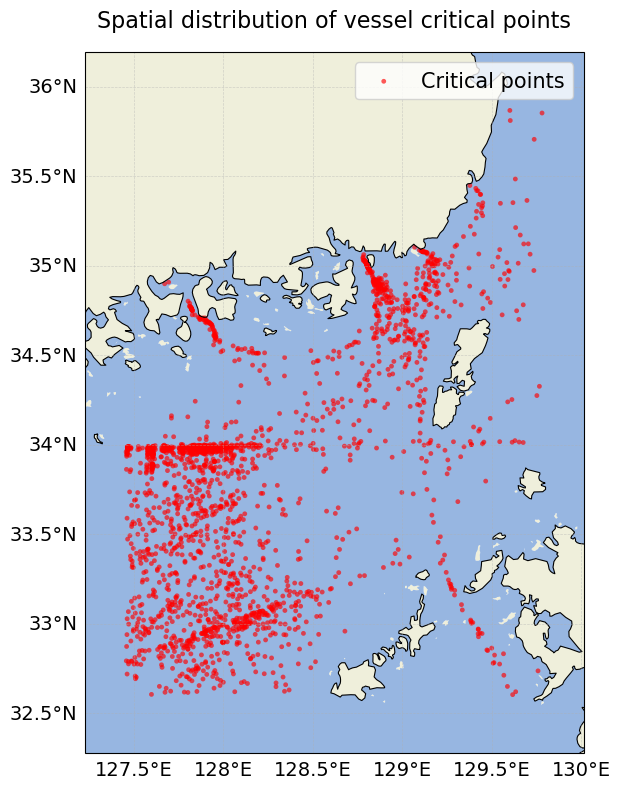

In [23]:
# =========================
# 1. Read critical points
# =========================
critical_path = "critical_points.csv"

if not os.path.exists(critical_path):
    raise FileNotFoundError(f"File not found: {critical_path}")

critical_df = pd.read_csv(critical_path, encoding="utf-8-sig")

print("Critical point data loaded successfully")
print("Data shape:", critical_df.shape)
print("Column names:", critical_df.columns.tolist())

# =========================
# 2. Check latitude and longitude fields
# =========================
lat_col = "Lat"
lon_col = "Lng"

critical_df[lat_col] = pd.to_numeric(critical_df[lat_col], errors="coerce")
critical_df[lon_col] = pd.to_numeric(critical_df[lon_col], errors="coerce")

critical_df = critical_df.dropna(subset=[lat_col, lon_col]).copy()

print("Number of valid critical points:", len(critical_df))

if len(critical_df) == 0:
    raise ValueError("No valid latitude and longitude values are available in the critical points.")

# =========================
# 3. Automatically set the map extent
# =========================
lon_min = critical_df[lon_col].min()
lon_max = critical_df[lon_col].max()
lat_min = critical_df[lat_col].min()
lat_max = critical_df[lat_col].max()

lon_buffer = max(0.1, (lon_max - lon_min) * 0.1)
lat_buffer = max(0.1, (lat_max - lat_min) * 0.1)

extent = [
    lon_min - lon_buffer,
    lon_max + lon_buffer,
    lat_min - lat_buffer,
    lat_max + lat_buffer
]

# =========================
# 4. Plot critical points
# =========================
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, linewidth=0.5)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)

# Plot critical points
ax.scatter(
    critical_df[lon_col],
    critical_df[lat_col],
    s=12,
    c="red",
    alpha=0.65,
    edgecolors="none",
    transform=ccrs.PlateCarree(),
    label="Critical points"
)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    linestyle="--",
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False

# Increase the font size of coordinate labels
gl.xlabel_style = {
    "size": 14,
}

gl.ylabel_style = {
    "size": 14,

}

# Title and legend
ax.set_title(
    "Spatial distribution of vessel critical points",
    fontsize=16,

    pad=18
)

ax.legend(
    loc="upper right",
    fontsize=15,
    frameon=True
)

plt.tight_layout()

plt.savefig('Critical_points.png', dpi = 900)
plt.show()


## 6. Cluster critical points with KMeans

The geographic coordinates are first converted into approximate planar coordinates in kilometers. KMeans is then applied to identify groups of critical locations.


Critical point data loaded successfully
Number of valid points: 2161
KMeans clustering completed
Number of clusters: 10

Number of points in each cluster:
cluster_id
0    342
1    303
2    268
3     49
4    296
5    133
6    255
7     94
8    301
9    120
Name: count, dtype: int64

Clustering results saved to: critical_points_kmeans.csv


/tmp/ipykernel_9485/3074310834.py:113: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10", n_clusters)


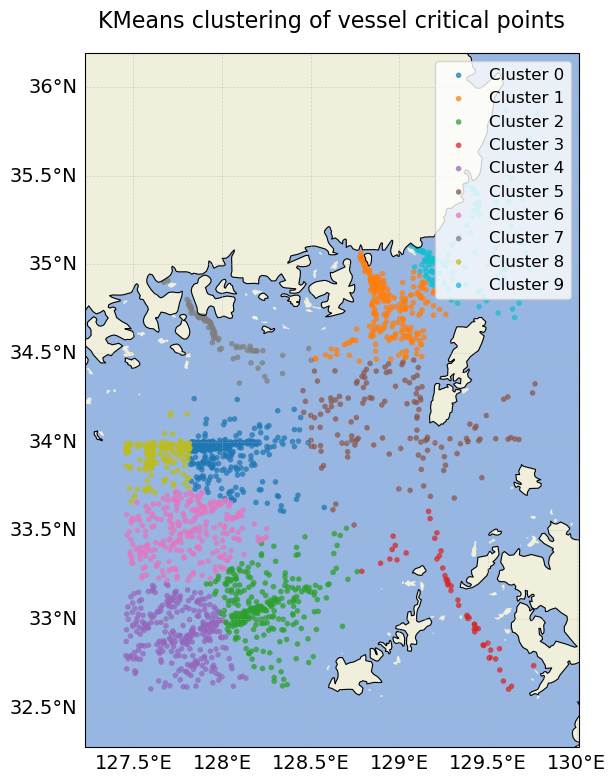

,IMO,Date/Time,Lat,Lng,Heading,SOG,COG,draught,Navigation status,_original_index,...,turn_angle_deg,time_gap_prev_min,time_gap_next_min,is_turn_critical,is_timegap_critical,is_critical_point,critical_reason,x_km,y_km,cluster_id
0,8320559,2021-09-14 08:43:00,34.760278,128.952222,145.0,10.1,144.0,8.5,Under Way,158188,...,17.767003,18.0,76.0,False,True,True,time_gap_gt_30min,11922.485168,3843.443914,1
1,8320559,2021-09-14 09:59:00,34.579444,129.011389,198.0,10.1,202.0,8.5,Under Way,158189,...,36.733473,76.0,6.0,False,True,True,time_gap_gt_30min,11927.955518,3823.449172,1
2,8320559,2021-09-14 18:32:00,33.152500,128.522500,192.0,11.2,195.0,8.5,Under Way,158260,...,0.752744,13.0,69.0,False,True,True,time_gap_gt_30min,11882.754509,3665.671925,2
3,8320559,2021-09-14 19:41:00,32.946944,128.447222,198.0,10.7,198.0,8.5,Under Way,158261,...,0.817305,69.0,97.0,False,True,True,time_gap_gt_30min,11875.794581,3642.943647,2
4,8320559,2021-09-14 21:18:00,32.660000,128.347778,177.0,10.7,184.0,8.5,Under Way,158262,...,30.765092,97.0,11.0,False,True,True,time_gap_gt_30min,11866.600285,3611.216200,2


In [57]:
# =========================
# 1. Parameter settings
# =========================
critical_path = "critical_points.csv"
output_cluster_path = "critical_points_kmeans.csv"

lat_col = "Lat"
lon_col = "Lng"

# Number of clusters; adjust this value based on the results
n_clusters = 10

# =========================
# 2. Read critical points
# =========================
if not os.path.exists(critical_path):
    raise FileNotFoundError(f"File not found: {critical_path}")

critical_df = pd.read_csv(critical_path, encoding="utf-8-sig")

critical_df[lat_col] = pd.to_numeric(critical_df[lat_col], errors="coerce")
critical_df[lon_col] = pd.to_numeric(critical_df[lon_col], errors="coerce")

critical_df = critical_df.dropna(subset=[lat_col, lon_col]).copy()

print("Critical point data loaded successfully")
print("Number of valid points:", len(critical_df))

if len(critical_df) == 0:
    raise ValueError("No valid latitude and longitude values are available in the critical points.")

if len(critical_df) < n_clusters:
    raise ValueError(
        f"The number of critical points {len(critical_df)} is smaller than n_clusters {n_clusters}; please reduce n_clusters."
    )

# =========================
# 3. Convert latitude and longitude to approximate planar coordinates
#    This avoids inconsistent distance scales caused by using raw coordinates.
# =========================
lat_mean = critical_df[lat_col].mean()

# Approximate conversion to kilometers
critical_df["x_km"] = critical_df[lon_col] * 111.32 * np.cos(np.radians(lat_mean))
critical_df["y_km"] = critical_df[lat_col] * 110.57

X = critical_df[["x_km", "y_km"]].values

# =========================
# 4. KMeans clustering
# =========================
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

critical_df["cluster_id"] = kmeans.fit_predict(X)

print("KMeans clustering completed")
print("Number of clusters:", n_clusters)

print("\nNumber of points in each cluster:")
print(critical_df["cluster_id"].value_counts().sort_index())

# Save critical points with cluster labels
critical_df.to_csv(output_cluster_path, index=False, encoding="utf-8-sig")
print("\nClustering results saved to:", output_cluster_path)

# =========================
# 5. Automatically set the map extent
# =========================
lon_min = critical_df[lon_col].min()
lon_max = critical_df[lon_col].max()
lat_min = critical_df[lat_col].min()
lat_max = critical_df[lat_col].max()

lon_buffer = max(0.2, (lon_max - lon_min) * 0.1)
lat_buffer = max(0.2, (lat_max - lat_min) * 0.1)

extent = [
    lon_min - lon_buffer,
    lon_max + lon_buffer,
    lat_min - lat_buffer,
    lat_max + lat_buffer
]

# =========================
# 6. Plot the clustering results
# =========================
fig = plt.figure(figsize=(6, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, linewidth=0.5)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)

# Use a discrete colormap
cmap = plt.cm.get_cmap("tab10", n_clusters)

for cluster_id in sorted(critical_df["cluster_id"].unique()):
    df_cluster = critical_df[critical_df["cluster_id"] == cluster_id]

    ax.scatter(
        df_cluster[lon_col],
        df_cluster[lat_col],
        s=16,
        alpha=0.75,
        color=cmap(cluster_id),
        edgecolors="none",
        transform=ccrs.PlateCarree(),
        label=f"Cluster {cluster_id}"
    )

# Add gridlines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    linestyle="--",
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {
    "size": 14,

}

gl.ylabel_style = {
    "size": 14,

}

# Title and legend
ax.set_title(
    "KMeans clustering of vessel critical points",
    fontsize=16,
    pad=18
)

ax.legend(
    loc="upper right",
    fontsize=12,
    frameon=True,
)

plt.tight_layout()
plt.savefig('Cluster_Critical_points10.png', dpi = 900)


plt.show()

critical_df.head()


## 7. Cluster trajectories with DTW and DBSCAN

Each trajectory is simplified using the Douglas-Peucker algorithm, and pairwise trajectory similarity is measured by Dynamic Time Warping. DBSCAN is then applied to the precomputed distance matrix to identify trajectory groups and noise trajectories.


AIS trajectory data loaded successfully
Total number of points: 428341
Number of trajectories: 3810

Trajectory simplification completed
Number of trajectories satisfying the minimum-point requirement: 3810
Average number of raw points: 112.41732283464567
Average number of points after DP simplification: 4.108923884514436
Average number of final points used for DTW: 4.108923884514436
Final number of trajectories used for DTW clustering: 400

Starting DTW distance matrix computation...
Processed 20/400 trajectories, computed DTW pairs: 7104, skipped pairs: 686
Processed 40/400 trajectories, computed DTW pairs: 13842, skipped pairs: 1338
Processed 60/400 trajectories, computed DTW pairs: 19945, skipped pairs: 2225
Processed 80/400 trajectories, computed DTW pairs: 26068, skipped pairs: 2692
Processed 100/400 trajectories, computed DTW pairs: 31445, skipped pairs: 3505
Processed 120/400 trajectories, computed DTW pairs: 36496, skipped pairs: 4244
Processed 140/400 trajectories, computed D

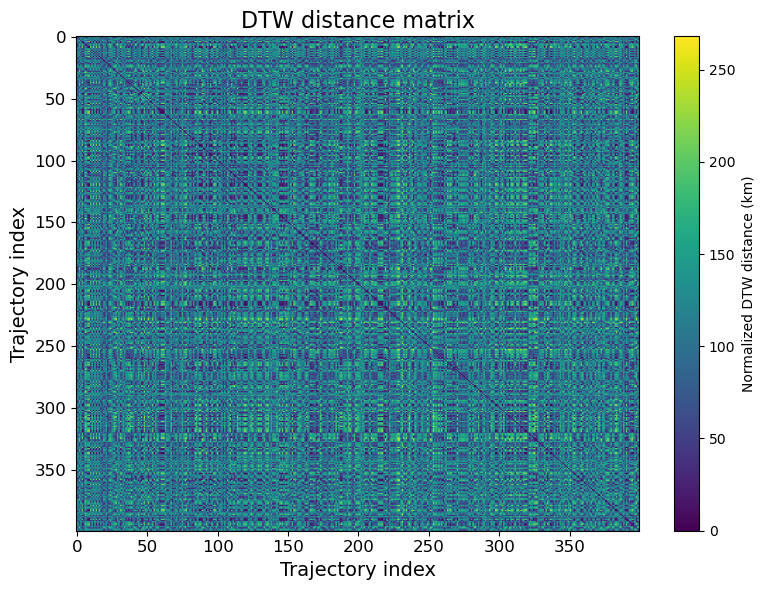

,trajectory_id,IMO,start_time,end_time,point_count,raw_used_point_count,dp_point_count,final_used_point_count,start_lat,start_lon,end_lat,end_lon,traj_cluster_id
0,2911,9665657,2021-05-19 12:15:00,2021-05-19 22:16:00,113,113,6,6,33.279444,127.456944,35.076389,129.121667,0
1,1644,9363376,2021-04-25 17:48:00,2021-04-26 03:12:00,108,108,6,6,34.136944,127.457222,35.089167,129.094167,0
2,2479,9595436,2021-04-11 12:02:00,2021-04-11 18:13:00,129,129,4,4,34.997222,129.778056,33.845556,127.467500,-1
3,1499,9351139,2021-07-02 04:46:00,2021-07-02 10:00:00,101,101,3,3,33.233889,127.968056,34.284444,129.769722,-1
4,1113,9308053,2021-01-29 15:03:00,2021-01-30 00:04:00,85,85,2,2,34.018056,129.770556,33.951111,127.464167,1


In [58]:
# =========================
# 1. Parameter settings
# =========================
trajectory_col = "trajectory_id"
time_col = "Date/Time"
lat_col = "Lat"
lon_col = "Lng"

# Minimum number of points per trajectory
min_points_per_traj = 5

# Douglas-Peucker simplification threshold, in kilometers
# A larger value gives stronger simplification and faster computation but preserves fewer trajectory details.
dp_epsilon_km = 3.0

# Apply uniform downsampling if a trajectory is still too long after DP simplification
max_points_after_dp = 30

# Number of trajectories randomly sampled for DTW computation
max_trajectories_for_dtw = 400

# Random seed for sampling
sample_random_state = 42

# DBSCAN parameters
eps_dtw_km = 25
min_samples = 10

output_traj_cluster_path = "trajectory_dtw_dbscan_clusters.csv"
output_point_cluster_path = "ais_with_trajectory_dtw_dbscan.csv"
output_dtw_matrix_path = "trajectory_dtw_distance_matrix.csv"

# =========================
# 2. Data preparation
# =========================
if "df_traj" not in globals():
    raise NameError("df_traj was not found. Please run the cell that generates trajectory_id first.")

df_work = df_traj.copy()

df_work[time_col] = pd.to_datetime(df_work[time_col], errors="coerce")
df_work[lat_col] = pd.to_numeric(df_work[lat_col], errors="coerce")
df_work[lon_col] = pd.to_numeric(df_work[lon_col], errors="coerce")

df_work = df_work.dropna(subset=[trajectory_col, time_col, lat_col, lon_col]).copy()
df_work = df_work.sort_values([trajectory_col, time_col]).reset_index(drop=True)

print("AIS trajectory data loaded successfully")
print("Total number of points:", len(df_work))
print("Number of trajectories:", df_work[trajectory_col].nunique())

# =========================
# 3. Convert latitude and longitude to approximate planar coordinates, in kilometers
# =========================
lat_mean = df_work[lat_col].mean()

df_work["x_km"] = df_work[lon_col] * 111.32 * np.cos(np.radians(lat_mean))
df_work["y_km"] = df_work[lat_col] * 110.57

# =========================
# 4. Douglas-Peucker trajectory simplification
# =========================
def point_to_segment_distance(points, start, end):
    """
    Compute perpendicular distances from multiple points to the segment from start to end.
    points: [n, 2]
    start: [2]
    end: [2]
    """
    seg = end - start
    seg_len2 = np.dot(seg, seg)

    if seg_len2 == 0:
        return np.linalg.norm(points - start, axis=1)

    t = np.sum((points - start) * seg, axis=1) / seg_len2
    t = np.clip(t, 0, 1)

    projection = start + t[:, None] * seg
    distances = np.linalg.norm(points - projection, axis=1)

    return distances


def douglas_peucker(points, epsilon):
    """
    Douglas-Peucker trajectory simplification.
    points: [n, 2]
    epsilon: distance threshold with the same unit as points; here the unit is kilometers.
    """
    n = len(points)

    if n <= 2:
        return points

    keep = np.zeros(n, dtype=bool)
    keep[0] = True
    keep[-1] = True

    stack = [(0, n - 1)]

    while stack:
        start_idx, end_idx = stack.pop()

        if end_idx <= start_idx + 1:
            continue

        segment_points = points[start_idx + 1:end_idx]
        start = points[start_idx]
        end = points[end_idx]

        distances = point_to_segment_distance(segment_points, start, end)

        max_dist_idx = np.argmax(distances)
        max_dist = distances[max_dist_idx]

        if max_dist > epsilon:
            real_idx = start_idx + 1 + max_dist_idx
            keep[real_idx] = True

            stack.append((start_idx, real_idx))
            stack.append((real_idx, end_idx))

    return points[keep]


def uniform_downsample(points, max_points):
    """
    Apply uniform downsampling to overly long simplified trajectories.
    """
    if max_points is None:
        return points

    n = len(points)

    if n <= max_points:
        return points

    idx = np.linspace(0, n - 1, max_points).astype(int)
    return points[idx]


# =========================
# 5. Build simplified trajectory sequences
# =========================
traj_dict = {}
traj_info = []

raw_point_counts = []
dp_point_counts = []
final_point_counts = []

for traj_id, group in df_work.groupby(trajectory_col):
    group = group.sort_values(time_col)

    if len(group) < min_points_per_traj:
        continue

    points = group[["x_km", "y_km"]].values

    # Remove consecutive duplicate points
    if len(points) > 1:
        diff = np.diff(points, axis=0)
        keep = np.r_[True, np.linalg.norm(diff, axis=1) > 1e-9]
        points = points[keep]

    if len(points) < min_points_per_traj:
        continue

    raw_n = len(points)

    # DP simplification
    points_dp = douglas_peucker(points, epsilon=dp_epsilon_km)
    dp_n = len(points_dp)

    # If the trajectory is still too long after DP simplification, apply uniform downsampling
    points_final = uniform_downsample(points_dp, max_points_after_dp)
    final_n = len(points_final)

    traj_dict[traj_id] = points_final

    raw_point_counts.append(raw_n)
    dp_point_counts.append(dp_n)
    final_point_counts.append(final_n)

    traj_info.append({
        trajectory_col: traj_id,
        "IMO": group["IMO"].iloc[0] if "IMO" in group.columns else np.nan,
        "start_time": group[time_col].min(),
        "end_time": group[time_col].max(),
        "point_count": len(group),
        "raw_used_point_count": raw_n,
        "dp_point_count": dp_n,
        "final_used_point_count": final_n,
        "start_lat": group[lat_col].iloc[0],
        "start_lon": group[lon_col].iloc[0],
        "end_lat": group[lat_col].iloc[-1],
        "end_lon": group[lon_col].iloc[-1]
    })

traj_ids = list(traj_dict.keys())
traj_info_df = pd.DataFrame(traj_info)

print("\nTrajectory simplification completed")
print("Number of trajectories satisfying the minimum-point requirement:", len(traj_ids))
print("Average number of raw points:", np.mean(raw_point_counts))
print("Average number of points after DP simplification:", np.mean(dp_point_counts))
print("Average number of final points used for DTW:", np.mean(final_point_counts))

if len(traj_ids) == 0:
    raise ValueError("No trajectory satisfies the minimum-point requirement. Please reduce min_points_per_traj.")

# =========================
# 6. Randomly sample trajectories for DTW clustering
# =========================
if len(traj_ids) > max_trajectories_for_dtw:
    rng = np.random.default_rng(sample_random_state)

    selected_traj_ids = rng.choice(
        traj_ids,
        size=max_trajectories_for_dtw,
        replace=False
    )

    selected_traj_ids = list(selected_traj_ids)

    traj_dict = {
        traj_id: traj_dict[traj_id]
        for traj_id in selected_traj_ids
    }

    traj_ids = selected_traj_ids

    # Ensure that the order of traj_info_df is exactly consistent with traj_ids
    traj_info_df = (
        traj_info_df
        .set_index(trajectory_col)
        .loc[traj_ids]
        .reset_index()
    )

else:
    selected_traj_ids = traj_ids

    traj_info_df = (
        traj_info_df
        .set_index(trajectory_col)
        .loc[traj_ids]
        .reset_index()
    )

n_traj = len(traj_ids)

print("Final number of trajectories used for DTW clustering:", n_traj)

if n_traj < min_samples:
    raise ValueError("The number of trajectories used for clustering is smaller than min_samples. Please reduce min_samples.")

# =========================
# 7. Compute trajectory bounding boxes to skip clearly dissimilar pairs
# =========================
bbox_dict = {}

for traj_id in traj_ids:
    pts = traj_dict[traj_id]
    bbox_dict[traj_id] = {
        "xmin": pts[:, 0].min(),
        "xmax": pts[:, 0].max(),
        "ymin": pts[:, 1].min(),
        "ymax": pts[:, 1].max()
    }


def bbox_min_distance(b1, b2):
    """
    Minimum distance between two bounding boxes.
    If the bounding boxes overlap, the distance is zero.
    """
    dx = max(b1["xmin"] - b2["xmax"], b2["xmin"] - b1["xmax"], 0)
    dy = max(b1["ymin"] - b2["ymax"], b2["ymin"] - b1["ymax"], 0)
    return np.sqrt(dx ** 2 + dy ** 2)

# =========================
# 8. Define the 2D DTW distance
# =========================
def dtw_distance_2d(seq_a, seq_b):
    """
    Compute the normalized DTW distance between two simplified 2D trajectories.
    The returned value is approximately measured in kilometers.
    """
    n = len(seq_a)
    m = len(seq_b)

    point_dist = np.linalg.norm(
        seq_a[:, None, :] - seq_b[None, :, :],
        axis=2
    )

    dtw = np.full((n + 1, m + 1), np.inf)
    steps = np.zeros((n + 1, m + 1), dtype=int)

    dtw[0, 0] = 0.0

    for i in range(1, n + 1):
        for j in range(1, m + 1):

            candidates_cost = [
                dtw[i - 1, j],
                dtw[i, j - 1],
                dtw[i - 1, j - 1]
            ]

            min_idx = int(np.argmin(candidates_cost))

            if min_idx == 0:
                min_cost = dtw[i - 1, j]
                min_step = steps[i - 1, j]
            elif min_idx == 1:
                min_cost = dtw[i, j - 1]
                min_step = steps[i, j - 1]
            else:
                min_cost = dtw[i - 1, j - 1]
                min_step = steps[i - 1, j - 1]

            dtw[i, j] = point_dist[i - 1, j - 1] + min_cost
            steps[i, j] = min_step + 1

    return dtw[n, m] / max(steps[n, m], 1)

# =========================
# 9. Compute the DTW distance matrix between trajectories
# =========================
distance_matrix = np.full((n_traj, n_traj), eps_dtw_km + 1.0)
np.fill_diagonal(distance_matrix, 0.0)

print("\nStarting DTW distance matrix computation...")

computed_pairs = 0
skipped_pairs = 0

for i in range(n_traj):
    traj_i = traj_ids[i]
    bbox_i = bbox_dict[traj_i]

    for j in range(i + 1, n_traj):
        traj_j = traj_ids[j]
        bbox_j = bbox_dict[traj_j]

        # If the minimum bounding-box distance is already larger than eps,
        # the two trajectories cannot be DBSCAN neighbors and can be skipped.
        if bbox_min_distance(bbox_i, bbox_j) > eps_dtw_km:
            skipped_pairs += 1
            continue

        dist = dtw_distance_2d(
            traj_dict[traj_i],
            traj_dict[traj_j]
        )

        distance_matrix[i, j] = dist
        distance_matrix[j, i] = dist
        computed_pairs += 1

    if (i + 1) % 20 == 0 or i == n_traj - 1:
        print(
            f"Processed {i + 1}/{n_traj} trajectories, "
            f"computed DTW pairs: {computed_pairs}, "
            f"skipped pairs: {skipped_pairs}"
        )

dtw_matrix_df = pd.DataFrame(
    distance_matrix,
    index=traj_ids,
    columns=traj_ids
)

dtw_matrix_df.to_csv(output_dtw_matrix_path, encoding="utf-8-sig")

print("\nDTW distance matrix computation completed")
print("Number of DTW pairs actually computed:", computed_pairs)
print("Number of DTW pairs skipped:", skipped_pairs)
print("DTW distance matrix saved to:", output_dtw_matrix_path)

# =========================
# 10. DBSCAN using the precomputed distance matrix
# =========================
def dbscan_precomputed(distance_matrix, eps, min_samples):
    """
    DBSCAN based on a precomputed distance matrix.
    -1 denotes noise trajectories.
    0, 1, 2, ... denote different trajectory clusters.
    """
    n = distance_matrix.shape[0]
    labels = np.full(n, -99, dtype=int)
    cluster_id = 0

    neighbors_list = [
        np.where(distance_matrix[i] <= eps)[0]
        for i in range(n)
    ]

    for i in range(n):
        if labels[i] != -99:
            continue

        neighbors = neighbors_list[i]

        if len(neighbors) < min_samples:
            labels[i] = -1
            continue

        labels[i] = cluster_id

        queue = deque(neighbors.tolist())

        while queue:
            point_idx = queue.popleft()

            if labels[point_idx] == -1:
                labels[point_idx] = cluster_id

            if labels[point_idx] != -99:
                continue

            labels[point_idx] = cluster_id

            point_neighbors = neighbors_list[point_idx]

            if len(point_neighbors) >= min_samples:
                for nb in point_neighbors:
                    if labels[nb] in [-99, -1]:
                        queue.append(nb)

        cluster_id += 1

    labels[labels == -99] = -1
    return labels

# =========================
# 11. Run DBSCAN trajectory clustering
# =========================
traj_labels = dbscan_precomputed(
    distance_matrix,
    eps=eps_dtw_km,
    min_samples=min_samples
)

traj_cluster_df = traj_info_df.copy()
traj_cluster_df["traj_cluster_id"] = traj_labels

traj_cluster_df.to_csv(output_traj_cluster_path, index=False, encoding="utf-8-sig")

print("\nDBSCAN trajectory clustering completed")
print("DP simplification threshold dp_epsilon_km:", dp_epsilon_km)
print("eps_dtw_km:", eps_dtw_km)
print("min_samples:", min_samples)
print("Trajectory clustering results saved to:", output_traj_cluster_path)

print("\nNumber of trajectories in each cluster:")
print(traj_cluster_df["traj_cluster_id"].value_counts().sort_index())

# =========================
# 12. Merge trajectory cluster labels back into AIS point data
# =========================
df_work_selected = df_work[
    df_work[trajectory_col].isin(selected_traj_ids)
].copy()

df_work_selected = df_work_selected.merge(
    traj_cluster_df[[trajectory_col, "traj_cluster_id"]],
    on=trajectory_col,
    how="left"
)

df_work_selected.to_csv(output_point_cluster_path, index=False, encoding="utf-8-sig")

print("\nAIS data with trajectory cluster labels saved to:", output_point_cluster_path)

# =========================
# 13. Plot the DTW distance matrix
# =========================
plt.figure(figsize=(8, 6))
plt.imshow(distance_matrix, aspect="auto")
plt.colorbar(label="Normalized DTW distance (km)")
plt.title("DTW distance matrix", fontsize=16)
plt.xlabel("Trajectory index", fontsize=14)
plt.ylabel("Trajectory index", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('distance_matrix.png', dpi = 900)
plt.show()

traj_cluster_df.head()


## 8. Visualize all trajectory clusters

This cell plots all clustered trajectories on one map. Noise trajectories are shown separately from normal clusters.


Trajectory clustering results loaded successfully
Data shape: (44389, 17)
Column names: ['IMO', 'Date/Time', 'Lat', 'Lng', 'Heading', 'SOG', 'COG', 'draught', 'Navigation status', '_original_index', 'prev_time', 'time_gap_from_prev_hour', 'is_new_trajectory', 'trajectory_id', 'x_km', 'y_km', 'traj_cluster_id']
Number of valid AIS points: 44389
Number of trajectories: 400
Number of clusters including noise: 10


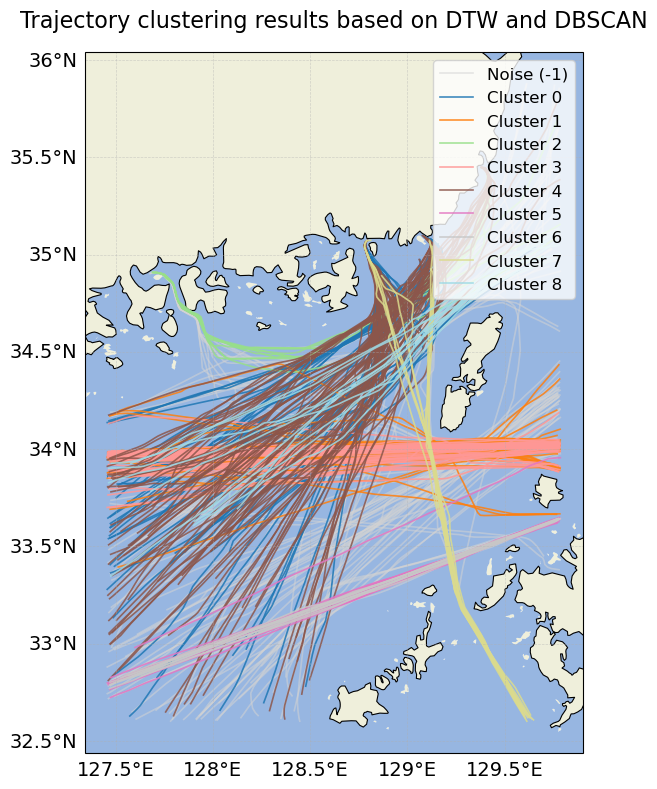

In [52]:
# =========================
# 1. Parameter settings
# =========================
input_path = "ais_with_trajectory_dtw_dbscan.csv"

trajectory_col = "trajectory_id"
cluster_col = "traj_cluster_id"
time_col = "Date/Time"
lat_col = "Lat"
lon_col = "Lng"

# Whether to show the legend
show_legend = True

# =========================
# 2. Read data
# =========================
if not os.path.exists(input_path):
    raise FileNotFoundError(f"File not found: {input_path}")

df_plot = pd.read_csv(input_path, encoding="utf-8-sig")

print("Trajectory clustering results loaded successfully")
print("Data shape:", df_plot.shape)
print("Column names:", df_plot.columns.tolist())

# =========================
# 3. Data preprocessing
# =========================
df_plot[time_col] = pd.to_datetime(df_plot[time_col], errors="coerce")
df_plot[lat_col] = pd.to_numeric(df_plot[lat_col], errors="coerce")
df_plot[lon_col] = pd.to_numeric(df_plot[lon_col], errors="coerce")
df_plot[cluster_col] = pd.to_numeric(df_plot[cluster_col], errors="coerce")

df_plot = df_plot.dropna(
    subset=[trajectory_col, cluster_col, time_col, lat_col, lon_col]
).copy()

df_plot = df_plot.sort_values([cluster_col, trajectory_col, time_col]).reset_index(drop=True)

print("Number of valid AIS points:", len(df_plot))
print("Number of trajectories:", df_plot[trajectory_col].nunique())
print("Number of clusters including noise:", df_plot[cluster_col].nunique())

if len(df_plot) == 0:
    raise ValueError("No valid trajectory data are available for plotting.")

# =========================
# 4. Set the map extent
# =========================
lon_min = df_plot[lon_col].min()
lon_max = df_plot[lon_col].max()
lat_min = df_plot[lat_col].min()
lat_max = df_plot[lat_col].max()

lon_buffer = max(0.1, (lon_max - lon_min) * 0.05)
lat_buffer = max(0.1, (lat_max - lat_min) * 0.05)

extent = [
    lon_min - lon_buffer,
    lon_max + lon_buffer,
    lat_min - lat_buffer,
    lat_max + lat_buffer
]

# =========================
# 5. Prepare colors
# =========================
unique_clusters = sorted(df_plot[cluster_col].unique())

normal_clusters = [c for c in unique_clusters if c != -1]
has_noise = -1 in unique_clusters

# Assign colors to normal clusters
cmap = plt.get_cmap("tab20", max(len(normal_clusters), 1))
cluster_color_dict = {}

for i, c in enumerate(normal_clusters):
    cluster_color_dict[c] = cmap(i)

# Use a unified gray color for noise
if has_noise:
    cluster_color_dict[-1] = "lightgray"

# =========================
# 6. Plot trajectories
# =========================
fig = plt.figure(figsize=(6, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add base-map features
ax.add_feature(cfeature.LAND, linewidth=0.5)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)

legend_used = set()

# Plot trajectories by cluster
for cluster_id in unique_clusters:
    df_cluster = df_plot[df_plot[cluster_col] == cluster_id]
    color = cluster_color_dict[cluster_id]

    for traj_id, traj_group in df_cluster.groupby(trajectory_col):
        traj_group = traj_group.sort_values(time_col)

        label = None
        if cluster_id not in legend_used:
            if cluster_id == -1:
                label = "Noise (-1)"
            else:
                label = f"Cluster {int(cluster_id)}"
            legend_used.add(cluster_id)

        ax.plot(
            traj_group[lon_col],
            traj_group[lat_col],
            color=color,
            linewidth=1.2,
            alpha=0.85 if cluster_id != -1 else 0.55,
            transform=ccrs.PlateCarree(),
            label=label
        )

# =========================
# 7. Add gridlines and labels
# =========================
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    linestyle="--",
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {
    "size": 14,

}

gl.ylabel_style = {
    "size": 14,

}

# =========================
# 8. Title and legend
# =========================
ax.set_title(
    "Trajectory clustering results based on DTW and DBSCAN",
    fontsize=16,

    pad=18
)

if show_legend:
    ax.legend(
        loc="upper right",
        fontsize=12,
        frameon=True,
        ncol=1
    )

plt.tight_layout()
plt.show()


## 9. Save one map for each trajectory cluster

This final visualization step exports a separate map for each trajectory cluster using a common map extent.


In [54]:
# =========================
# 1. Parameter settings
# =========================
input_path = "ais_with_trajectory_dtw_dbscan.csv"
output_dir = "trajectory_cluster_maps"

trajectory_col = "trajectory_id"
cluster_col = "traj_cluster_id"
time_col = "Date/Time"
lat_col = "Lat"
lon_col = "Lng"

show_legend = True

# Fixed figure size
figure_size = (6, 8)

# Fixed output resolution
save_dpi = 900

os.makedirs(output_dir, exist_ok=True)

# =========================
# 2. Read data
# =========================
if not os.path.exists(input_path):
    raise FileNotFoundError(f"File not found: {input_path}")

df_all = pd.read_csv(input_path, encoding="utf-8-sig")

print("Trajectory clustering results loaded successfully")
print("Data shape:", df_all.shape)
print("Column names:", df_all.columns.tolist())

# =========================
# 3. Data preprocessing
# =========================
df_all[time_col] = pd.to_datetime(df_all[time_col], errors="coerce")
df_all[lat_col] = pd.to_numeric(df_all[lat_col], errors="coerce")
df_all[lon_col] = pd.to_numeric(df_all[lon_col], errors="coerce")
df_all[cluster_col] = pd.to_numeric(df_all[cluster_col], errors="coerce")

df_all = df_all.dropna(
    subset=[trajectory_col, cluster_col, time_col, lat_col, lon_col]
).copy()

df_all = df_all.sort_values([cluster_col, trajectory_col, time_col]).reset_index(drop=True)

print("Number of valid AIS points:", len(df_all))
print("Number of trajectories:", df_all[trajectory_col].nunique())
print("Number of clusters including noise:", df_all[cluster_col].nunique())

if len(df_all) == 0:
    raise ValueError("No valid trajectory data are available for plotting.")

# =========================
# 4. Fixed map extent
#    The extent is computed from all trajectories and shared by all cluster maps.
# =========================
lon_min = df_all[lon_col].min()
lon_max = df_all[lon_col].max()
lat_min = df_all[lat_col].min()
lat_max = df_all[lat_col].max()

lon_buffer = max(0.1, (lon_max - lon_min) * 0.05)
lat_buffer = max(0.1, (lat_max - lat_min) * 0.05)

fixed_extent = [
    lon_min - lon_buffer,
    lon_max + lon_buffer,
    lat_min - lat_buffer,
    lat_max + lat_buffer
]

print("Fixed map extent fixed_extent:")
print(fixed_extent)

# To manually fix the map extent, uncomment the following line and modify the values.
# fixed_extent = [120, 123, 21, 26]  # [lon_min, lon_max, lat_min, lat_max]

# =========================
# 5. Prepare colors
# =========================
unique_clusters = sorted(df_all[cluster_col].unique())

normal_clusters = [c for c in unique_clusters if c != -1]
has_noise = -1 in unique_clusters

cmap = plt.get_cmap("tab20", max(len(normal_clusters), 1))
cluster_color_dict = {}

for i, c in enumerate(normal_clusters):
    cluster_color_dict[c] = cmap(i)

if has_noise:
    cluster_color_dict[-1] = "lightgray"

# =========================
# 6. Plot and save each cluster separately
# =========================
for cluster_id in unique_clusters:
    df_plot = df_all[df_all[cluster_col] == cluster_id].copy()

    if len(df_plot) == 0:
        continue

    fig = plt.figure(figsize=figure_size)
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Use the same map extent for all clusters
    ax.set_extent(fixed_extent, crs=ccrs.PlateCarree())

    # Add base-map features
    ax.add_feature(cfeature.LAND, linewidth=0.5)
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)

    legend_used = set()
    color = cluster_color_dict[cluster_id]

    # Plot all trajectories in the current cluster
    for traj_id, traj_group in df_plot.groupby(trajectory_col):
        traj_group = traj_group.sort_values(time_col)

        label = None
        if cluster_id not in legend_used:
            if cluster_id == -1:
                label = "Noise (-1)"
            else:
                label = f"Cluster {int(cluster_id)}"
            legend_used.add(cluster_id)

        ax.plot(
            traj_group[lon_col],
            traj_group[lat_col],
            color=color,
            linewidth=1.2,
            alpha=0.85 if cluster_id != -1 else 0.55,
            transform=ccrs.PlateCarree(),
            label=label
        )

    # =========================
    # 7. Add gridlines and labels
    # =========================
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        linestyle="--",
        alpha=0.5
    )

    gl.top_labels = False
    gl.right_labels = False

    gl.xlabel_style = {
        "size": 14,
    }

    gl.ylabel_style = {
        "size": 14,
    }

    # =========================
    # 8. Title and legend
    # =========================
    if cluster_id == -1:
        title_text = "Trajectory clustering results: Noise (-1)"
        save_name = "cluster_-1_noise.png"
    else:
        title_text = f"Trajectory clustering results: Cluster {int(cluster_id)}"
        save_name = f"cluster_{int(cluster_id)}.png"

    ax.set_title(
        title_text,
        fontsize=16,
        pad=18
    )

    if show_legend:
        ax.legend(
            loc="upper right",
            fontsize=12,
            frameon=True,
            ncol=1
        )

    plt.tight_layout()

    save_path = os.path.join(output_dir, save_name)
    plt.savefig(save_path, dpi=save_dpi, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {save_path}")

print("\nAll cluster trajectory maps have been plotted and saved.")


Trajectory clustering results loaded successfully
Data shape: (44389, 17)
Column names: ['IMO', 'Date/Time', 'Lat', 'Lng', 'Heading', 'SOG', 'COG', 'draught', 'Navigation status', '_original_index', 'prev_time', 'time_gap_from_prev_hour', 'is_new_trajectory', 'trajectory_id', 'x_km', 'y_km', 'traj_cluster_id']
Number of valid AIS points: 44389
Number of trajectories: 400
Number of clusters including noise: 10
Fixed map extent fixed_extent:
[127.34051388888889, 129.9019861111111, 32.438166666666675, 36.04127777777777]
Saved: trajectory_cluster_maps/cluster_-1_noise.png
Saved: trajectory_cluster_maps/cluster_0.png
Saved: trajectory_cluster_maps/cluster_1.png
Saved: trajectory_cluster_maps/cluster_2.png
Saved: trajectory_cluster_maps/cluster_3.png
Saved: trajectory_cluster_maps/cluster_4.png
Saved: trajectory_cluster_maps/cluster_5.png
Saved: trajectory_cluster_maps/cluster_6.png
Saved: trajectory_cluster_maps/cluster_7.png
Saved: trajectory_cluster_maps/cluster_8.png

All cluster traject